In [65]:
include("parisiSolvers.jl")
using Plots
using Optim
using ADTypes: AutoForwardDiff
import ForwardDiff

### Description

Instead of optimizing directly over the coefficients of the piecewise constant function $\gamma_K(t)$, we optimize over an intermediate 
    parametrization of $\gamma_K(t)$, which automatically enforces monotonicity and boundedness.
Specifically, we use the following parametrizations:

$$g_k = \sum_{i=1}^k \log\!\left(1 + e^{\theta_i}\right)$$


$$g_k = \sum_{i=1}^k \frac{e^{\theta_i}}{\sum_{j=1}^K e^{\theta_j}}$$

Both enforce monotonicity and nonnegativity, and the second also enforces an upper bound of 1.

In [6]:
K = 10
tgrid = collect(range(0.0, 1.0, length=K+1));

theta0 = log.(fill(0.05, K))  
g0 = softplus(theta0);

### Pure spin, $p=3$

In [8]:
objective_p3 = make_objective(tgrid; p=3, L=8.0, Nx=1001, Q=40)
@time res_p3 = optimize(objective_p3, theta0, LBFGS(); autodiff=AutoForwardDiff()) 


  8.086337 seconds (156.38 k allocations: 17.334 GiB, 43.31% gc time, 0.04% compilation time)


 * Status: success

 * Candidate solution
    Final objective value:     1.150579e+00

 * Found with
    Algorithm:     L-BFGS

 * Convergence measures
    |x - x'|               = 0.00e+00 ≤ 0.0e+00
    |x - x'|/|x'|          = 0.00e+00 ≤ 0.0e+00
    |f(x) - f(x')|         = 0.00e+00 ≤ 0.0e+00
    |f(x) - f(x')|/|f(x')| = 0.00e+00 ≤ 0.0e+00
    |g(x)|                 = 1.80e-03 ≰ 1.0e-08

 * Work counters
    Seconds run:   8  (vs limit Inf)
    Iterations:    73
    f(x) calls:    174
    ∇f(x) calls:   174
    ∇f(x)ᵀv calls: 0


In [9]:
theta_star_p3 = Optim.minimizer(res_p3)
g_star_p3 = softplus(theta_star_p3)

println("Optimized P(gamma) (p=3) = ", objective_p3(theta_star_p3))

Optimized P(gamma) (p=3) = 1.1505790804832279


### Pure spin, $p=2$

In [10]:
objective_p2 = make_objective(tgrid; p=2, L=8.0, Nx=1001, Q=40)
@time res_p2 = optimize(objective_p2, theta0, LBFGS(); autodiff=AutoForwardDiff()) 

  8.759096 seconds (151.29 k allocations: 16.736 GiB, 47.44% gc time)


 * Status: success

 * Candidate solution
    Final objective value:     1.079384e+00

 * Found with
    Algorithm:     L-BFGS

 * Convergence measures
    |x - x'|               = 3.40e-04 ≰ 0.0e+00
    |x - x'|/|x'|          = 1.13e-04 ≰ 0.0e+00
    |f(x) - f(x')|         = 4.92e-13 ≰ 0.0e+00
    |f(x) - f(x')|/|f(x')| = 4.56e-13 ≰ 0.0e+00
    |g(x)|                 = 6.35e-09 ≤ 1.0e-08

 * Work counters
    Seconds run:   9  (vs limit Inf)
    Iterations:    136
    f(x) calls:    168
    ∇f(x) calls:   168
    ∇f(x)ᵀv calls: 0


In [11]:
theta_star_p2 = Optim.minimizer(res_p2)
g_star_p2 = softplus(theta_star_p2)

println("Optimized P(gamma) (p=2) = ", objective_p2(theta_star_p2))

Optimized P(gamma) (p=2) = 1.0793839143136628


### Pure spin, $p=4$

In [12]:
objective_p4 = make_objective(tgrid; p=4, L=8.0, Nx=1001, Q=40)
@time res_p4 = optimize(objective_p4, theta0, LBFGS(); autodiff=AutoForwardDiff()) 

  6.236628 seconds (126.96 k allocations: 14.046 GiB, 41.33% gc time)


 * Status: success

 * Candidate solution
    Final objective value:     1.167495e+00

 * Found with
    Algorithm:     L-BFGS

 * Convergence measures
    |x - x'|               = 1.08e+02 ≰ 0.0e+00
    |x - x'|/|x'|          = 3.96e-02 ≰ 0.0e+00
    |f(x) - f(x')|         = 1.86e-12 ≰ 0.0e+00
    |f(x) - f(x')|/|f(x')| = 1.60e-12 ≰ 0.0e+00
    |g(x)|                 = 4.41e-09 ≤ 1.0e-08

 * Work counters
    Seconds run:   6  (vs limit Inf)
    Iterations:    112
    f(x) calls:    141
    ∇f(x) calls:   141
    ∇f(x)ᵀv calls: 0


In [13]:
theta_star_p4 = Optim.minimizer(res_p4)
g_star_p4 = softplus(theta_star_p4)

println("Optimized P(gamma) (p=4) = ", objective_p4(theta_star_p4))

Optimized P(gamma) (p=4) = 1.1674951368035216


### Plots

A priori we expect $p=3$ to have  $p=2$ to not be flat. For $p=3$ we don't really know, but expect flatness. For $p=4$ we expect flatness. 

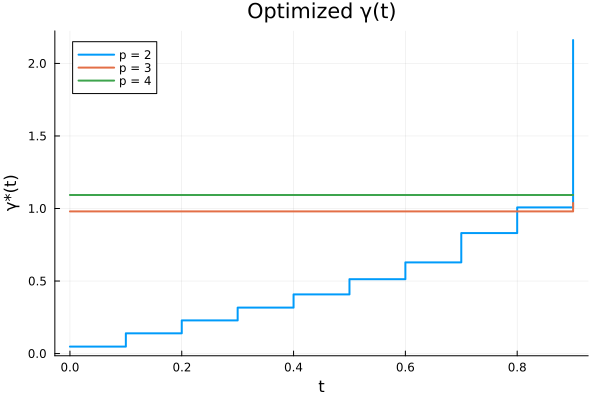

In [14]:
plot(
    tgrid[1:end-1],
    g_star_p2,
    seriestype=:steppost,
    xlabel="t",
    ylabel="γ*(t)",
    linewidth=2,
    label="p = 2",
    title = "Optimized γ(t)",
)

plot!(
    tgrid[1:end-1],
    g_star_p3,
    seriestype=:steppost,
    xlabel="t",
    ylabel="γ*(t)",
    linewidth=2,
    label="p = 3"
)


plot!(
    tgrid[1:end-1],
    g_star_p4,
    seriestype=:steppost,
    xlabel="t",
    ylabel="γ*(t)",
    linewidth=2,
    label="p = 4"
)

### $K = 2, 3, 4, 5, 6, 7$

  3.223702 seconds (80.54 k allocations: 7.939 GiB, 49.51% gc time)


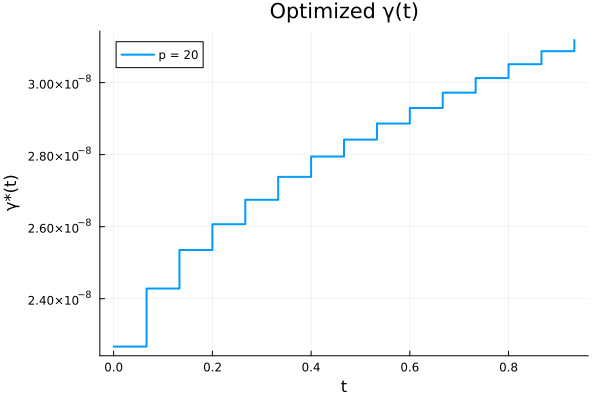

In [ ]:
# Try other theta to g mapping to force that gamma is in [0,1]
p_vals = 3:8
K = 20
theta_map = softplus


tgrid = collect(range(0.0, 1.0, length=K+1));

lower = zeros(K)
upper = ones(K)

theta0 = log.(fill(0.05, K))  
g0 = theta_map(theta0);

g_stars = Dict{Int, Vector{Float64}}()

for p in p_vals
    objective = make_objective(tgrid; p=p, L=8.0, Nx=1001, Q=40, theta_to_g=theta_map)
    @time res = optimize(objective, theta0, LBFGS(); autodiff=AutoForwardDiff()) 
    theta_star = Optim.minimizer(res)
    g_star = theta_map(theta_star)
    g_stars[p] = g_star
end 


In [ ]:
subplots = [
    plot(tgrid[1:end-1], g_stars[p],
        seriestype = :steppost, linewidth = 2,
        title = "p = $p", xlabel = "t", ylabel = "γ*(t)", legend = false)
    for p in p_vals
]
plt_grid = plot(subplots..., layout = (2, 3), size = (900, 500), plot_title = "γ(t) ≥ 0 with softplus")

display(plt_grid)

In [ ]:
# Try other theta to g mapping to force that gamma is in [0,1]
p_vals = 3:8
K = 20
theta_map = softmax_stable


tgrid = collect(range(0.0, 1.0, length=K+1));

lower = zeros(K)
upper = ones(K)

theta0 = log.(fill(0.05, K))  
g0 = theta_map(theta0);

g_stars = Dict{Int, Vector{Float64}}()

for p in p_vals
    objective = make_objective(tgrid; p=p, L=8.0, Nx=1001, Q=40, theta_to_g=theta_map)
    @time res = optimize(objective, theta0, LBFGS(); autodiff=AutoForwardDiff()) 
    theta_star = Optim.minimizer(res)
    g_star = theta_map(theta_star)
    g_stars[p] = g_star
end 


In [ ]:
subplots = [
    plot(tgrid[1:end-1], g_stars[p],
        seriestype = :steppost, linewidth = 2,
        title = "p = $p", xlabel = "t", ylabel = "γ*(t)", legend = false)
    for p in p_vals
]
plt_grid = plot(subplots..., layout = (2, 3), size = (900, 500), plot_title = "γ(t) ∈ [0,1] with softmax")

display(plt_grid)